In [41]:
discount = 100 * 0.9
print(discount)

90.0


In [42]:
import seaborn as sns

import pandas as pd
import matplotlib.pyplot as plt

t = sns.load_dataset("titanic")
df_t = pd.DataFrame(t)

df_t.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [43]:
df_t["fair_age_ratio"] = df_t["fare"] / (df_t["age"] +1)

df_t.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,fair_age_ratio
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,0.315217
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,1.827777
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,0.293519
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,1.475000
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,0.223611


In [44]:
pclass_embark =df_t.groupby(["class","embark_town"]).agg({"fare":"mean","age":"mean","survived":"count"})
pclass_embark.head()

C:\Users\user\AppData\Local\Temp\ipykernel_29060\4275321264.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pclass_embark =df_t.groupby(["class","embark_town"]).agg({"fare":"mean","age":"mean","survived":"count"})


fare        age  survived
class  embark_town                                 
First  Cherbourg    104.718529  38.027027        85
       Queenstown    90.000000  38.500000         2
       Southampton   70.364862  38.152037       127
Second Cherbourg     25.358335  22.766667        17
       Queenstown    12.350000  43.500000         3

In [45]:
print(df_t.isnull().sum())

survived            0
pclass              0
sex                 0
age               177
sibsp               0
parch               0
fare                0
embarked            2
class               0
who                 0
adult_male          0
deck              688
embark_town         2
alive               0
alone               0
fair_age_ratio    177
dtype: int64


In [46]:
print(df_t.shape)

(891, 16)


In [47]:
cleand_df = df_t.drop(columns=["deck"])

cleand_df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone,fair_age_ratio
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False,0.315217
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False,1.827777
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True,0.293519
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False,1.475000
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True,0.223611


In [48]:
cleand_df.describe()

,survived,pclass,age,sibsp,parch,fare,fair_age_ratio
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000,714.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208,1.817443
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429,4.435006
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400,0.329130
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200,0.541998
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000,1.574971
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200,78.932292


In [49]:
sqr_std = 14.52 ** 2
print(sqr_std)

210.8304


In [50]:
cleand_df['age'] =cleand_df['age'].fillna(cleand_df['age'].median())

cleand_df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone,fair_age_ratio
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False,0.315217
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False,1.827777
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True,0.293519
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False,1.475000
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True,0.223611


In [51]:
cleand_df['embarked'] = cleand_df['embarked'].fillna(cleand_df['embarked'].mode()[0])
cleand_df['embark_town'] = cleand_df['embark_town'].fillna(cleand_df['embark_town'].mode()[0])


In [52]:
cleand_df.isnull().sum()

survived            0
pclass              0
sex                 0
age                 0
sibsp               0
parch               0
fare                0
embarked            0
class               0
who                 0
adult_male          0
embark_town         0
alive               0
alone               0
fair_age_ratio    177
dtype: int64

In [53]:
cleand_df['fair_age_ratio'] = cleand_df['fair_age_ratio'].fillna(cleand_df['fair_age_ratio'].median())
cleand_df.isnull().sum()

survived          0
pclass            0
sex               0
age               0
sibsp             0
parch             0
fare              0
embarked          0
class             0
who               0
adult_male        0
embark_town       0
alive             0
alone             0
fair_age_ratio    0
dtype: int64

In [54]:
cleand_df["embarked"].mode()

0    S
Name: embarked, dtype: object

In [55]:
cleand_df["embark_town"].mode()

0    Southampton
Name: embark_town, dtype: object

<Axes: xlabel='class', ylabel='age'>

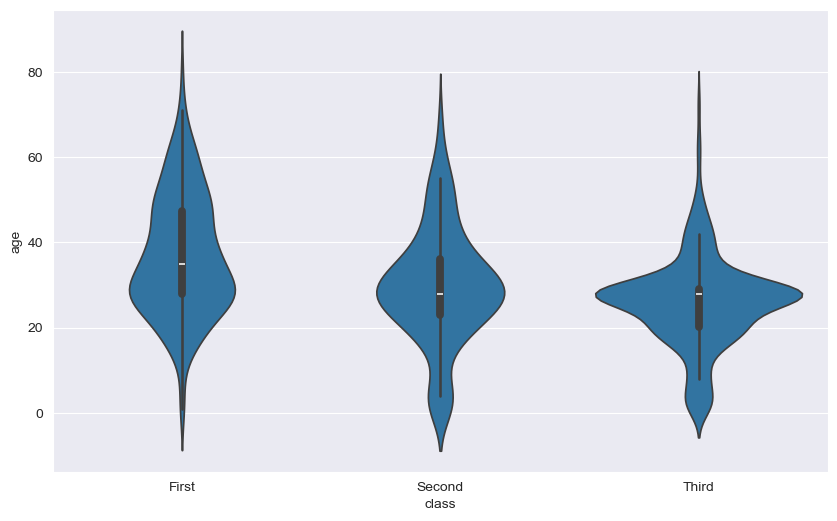

In [56]:
plt.figure(figsize=[10,6])
sns.violinplot(data=cleand_df,x=cleand_df['class'],y=cleand_df['age'])